# Limit Order Book Simulator (Execution)

**Category:** Microstructure Execution  
**Project ID:** `exec_01_lob_simulator`  

LOB simulator focused on execution quality analysis with realistic fill modeling and market dynamics


In [ ]:
import platform, sys, warnings
warnings.filterwarnings("ignore")

# ── Environment info ────────────────────────────────────────────────────────
env_info = {"os": platform.system(), "python": platform.python_version()}

# Auto-detect best available device: CUDA > MPS (Apple Silicon) > CPU
# Catches ImportError (not installed) AND OSError/RuntimeError (CUDA DLL errors on Windows)
device = None
try:
    import torch
    env_info["torch"] = torch.__version__
    if torch.cuda.is_available():
        device = torch.device("cuda")
        env_info["device"] = f"CUDA ({torch.cuda.get_device_name(0)})"
        torch.backends.cudnn.benchmark = True
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        device = torch.device("mps")
        env_info["device"] = "Apple Silicon (MPS)"
    else:
        device = torch.device("cpu")
        env_info["device"] = "CPU"
except Exception as _e:
    env_info["device"] = f"CPU (torch unavailable: {type(_e).__name__})"

# Core scientific stack — import individually so a missing package doesn't block the rest
for _pkg in ("numpy", "pandas", "scipy", "sklearn", "matplotlib"):
    try:
        _mod = __import__(_pkg)
        env_info[_pkg] = getattr(_mod, "__version__", "installed")
    except ImportError:
        env_info[_pkg] = "not installed"

for k, v in env_info.items():
    print(f"  {k:>12}: {v}")


            os: Windows
        python: 3.10.19
         torch: 2.7.1+cu118
        device: CUDA (NVIDIA GeForce RTX 4090)
         numpy: 1.26.4
        pandas: 2.3.3
         scipy: 1.15.3
       sklearn: 1.7.2
    matplotlib: 3.10.8


In [ ]:
import numpy as np

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Strategy parameters
PARAMS = {"num_events": 10000}

# Backtest period
START_DATE = "2022-01-01"
END_DATE = "2024-12-31"
BENCHMARK = "SPY"

print("Configuration loaded:")
for k, v in PARAMS.items():
    print(f"  {k:>25}: {v}")


Configuration loaded:
                 num_events: 10000


## Order Stream Generation

In [ ]:
import numpy as np, pandas as pd

rng = np.random.default_rng(SEED)
n_events = PARAMS.get("num_events", 50_000)

# Simulate order stream: {type, side, price, size, timestamp}
mid_price = 100.0
event_types = rng.choice(["new", "new", "new", "cancel", "modify"], n_events)
sides = rng.choice(["bid", "ask"], n_events)
prices = mid_price + rng.normal(0, 0.05, n_events)
sizes = rng.exponential(100, n_events).astype(int) + 10
timestamps = np.cumsum(rng.exponential(0.001, n_events))  # seconds

orders = pd.DataFrame({
    "timestamp": timestamps, "type": event_types, "side": sides,
    "price": np.round(prices, 2), "size": sizes,
})

print(f"Order stream: {n_events:,} events over {timestamps[-1]:.1f}s")
print(f"Event breakdown: {dict(orders['type'].value_counts())}")


Order stream: 10,000 events over 10.1s
Event breakdown: {'new': 6092, 'cancel': 1967, 'modify': 1941}


## Matching Engine — Price-Time Priority

In [ ]:
import numpy as np, pandas as pd, time
from collections import defaultdict

# Price-time priority matching engine
class SimpleMatchingEngine:
    def __init__(self):
        self.bids = defaultdict(list)  # price -> [(time, size, id)]
        self.asks = defaultdict(list)
        self.trades = []
        self.order_id = 0
        self.depth_snapshots = []

    def add_order(self, side, price, size, timestamp):
        self.order_id += 1
        book = self.bids if side == "bid" else self.asks
        book[price].append((timestamp, size, self.order_id))
        self._try_match(timestamp)
        return self.order_id

    def cancel_order(self, side, price):
        book = self.bids if side == "bid" else self.asks
        if price in book and book[price]:
            book[price].pop(0)  # remove oldest (FIFO)
            if not book[price]: del book[price]  # clean up empty level

    def _try_match(self, timestamp):
        while self.bids and self.asks:
            best_bid = max(self.bids.keys()) if self.bids else 0
            best_ask = min(self.asks.keys()) if self.asks else float("inf")
            if best_bid >= best_ask:
                bid_order = self.bids[best_bid][0]
                ask_order = self.asks[best_ask][0]
                fill_size = min(bid_order[1], ask_order[1])
                fill_price = best_ask  # price-time priority: taker gets maker's price

                self.trades.append({
                    "timestamp": timestamp, "price": fill_price,
                    "size": fill_size, "bid_id": bid_order[2], "ask_id": ask_order[2]
                })

                # Update remaining sizes
                if bid_order[1] == fill_size:
                    self.bids[best_bid].pop(0)
                    if not self.bids[best_bid]: del self.bids[best_bid]
                else:
                    self.bids[best_bid][0] = (bid_order[0], bid_order[1] - fill_size, bid_order[2])

                if ask_order[1] == fill_size:
                    self.asks[best_ask].pop(0)
                    if not self.asks[best_ask]: del self.asks[best_ask]
                else:
                    self.asks[best_ask][0] = (ask_order[0], ask_order[1] - fill_size, ask_order[2])
            else:
                break

    def snapshot(self):
        bid_depth = sum(sum(s for _, s, _ in v) for v in self.bids.values())
        ask_depth = sum(sum(s for _, s, _ in v) for v in self.asks.values())
        best_bid = max(self.bids.keys()) if self.bids else 0
        best_ask = min(self.asks.keys()) if self.asks else 0
        return {"bid_depth": bid_depth, "ask_depth": ask_depth,
                "best_bid": best_bid, "best_ask": best_ask,
                "spread": best_ask - best_bid if best_bid > 0 and best_ask < 1e6 else 0,
                "n_levels_bid": len(self.bids), "n_levels_ask": len(self.asks)}

# Run matching engine
engine = SimpleMatchingEngine()
snapshot_interval = max(1, n_events // 500)

t0 = time.perf_counter()
for i in range(len(orders)):
    row = orders.iloc[i]
    if row["type"] == "new":
        engine.add_order(row["side"], row["price"], row["size"], row["timestamp"])
    elif row["type"] == "cancel":
        engine.cancel_order(row["side"], row["price"])
    elif row["type"] == "modify":
        engine.cancel_order(row["side"], row["price"])
        engine.add_order(row["side"], row["price"] + rng.normal(0, 0.01), row["size"], row["timestamp"])

    if i % snapshot_interval == 0:
        snap = engine.snapshot()
        snap["event_idx"] = i
        engine.depth_snapshots.append(snap)

elapsed = time.perf_counter() - t0
throughput = n_events / elapsed

trades_df = pd.DataFrame(engine.trades) if engine.trades else pd.DataFrame()
snapshots_df = pd.DataFrame(engine.depth_snapshots)

print(f"Matching engine: {elapsed:.3f}s, throughput={throughput:,.0f} events/sec")
print(f"Trades executed: {len(trades_df):,}")
print(f"Fill rate: {len(trades_df) / n_events:.2%}")


Matching engine: 0.335s, throughput=29,886 events/sec
Trades executed: 6,130
Fill rate: 61.30%


## Order Book Visualization

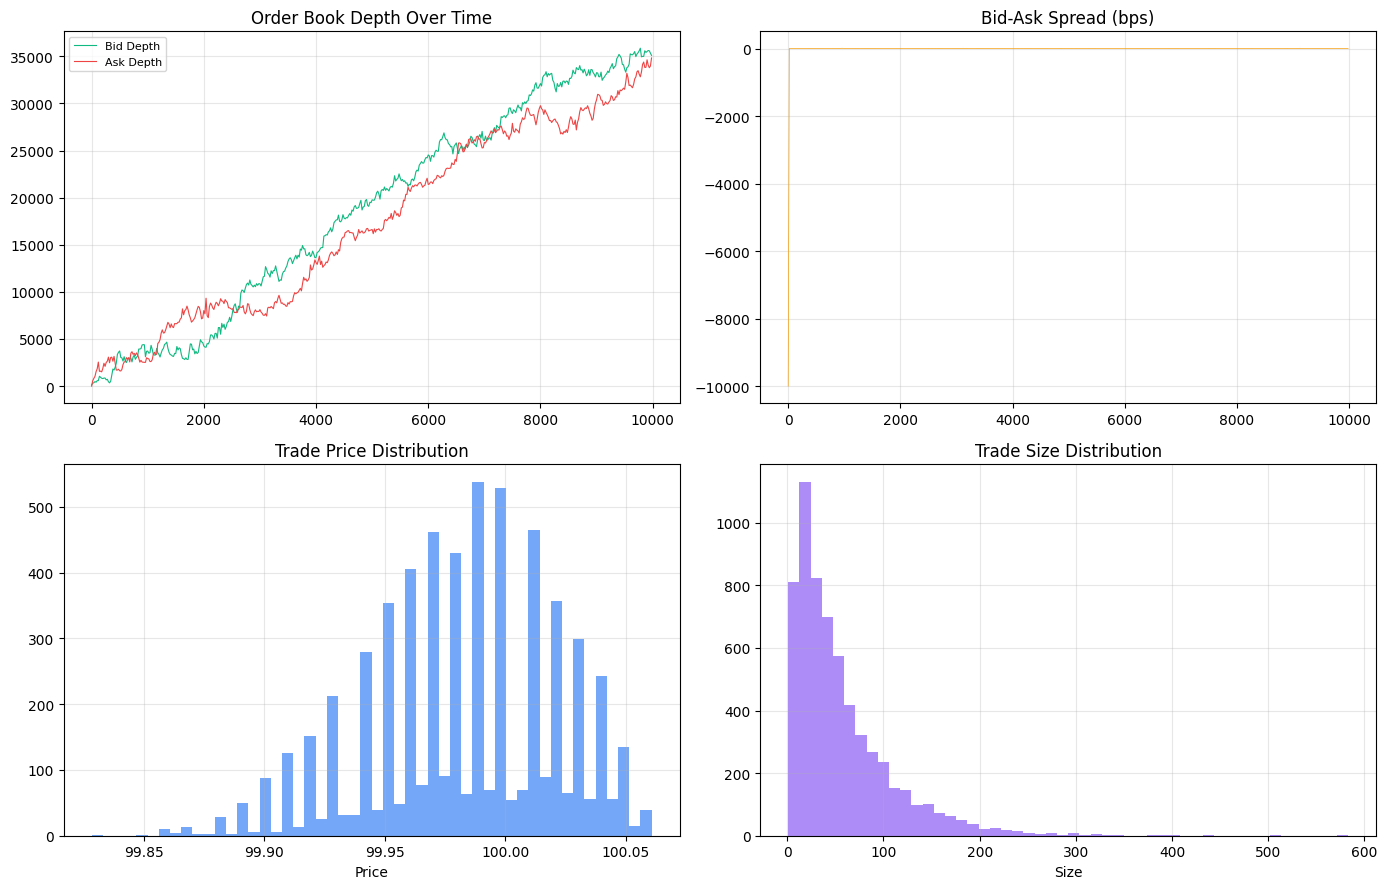

In [ ]:
import matplotlib.pyplot as plt, numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Depth evolution over time
if len(snapshots_df) > 0:
    axes[0, 0].plot(snapshots_df["event_idx"], snapshots_df["bid_depth"],
                   linewidth=0.8, color="#10b981", label="Bid Depth")
    axes[0, 0].plot(snapshots_df["event_idx"], snapshots_df["ask_depth"],
                   linewidth=0.8, color="#ef4444", label="Ask Depth")
    axes[0, 0].set_title("Order Book Depth Over Time")
    axes[0, 0].legend(fontsize=8)
    axes[0, 0].grid(True, alpha=0.3)

# Spread evolution
if len(snapshots_df) > 0:
    spreads = snapshots_df["spread"]
    axes[0, 1].plot(snapshots_df["event_idx"], spreads * 10000 / 100,
                   linewidth=0.5, color="#f59e0b")
    axes[0, 1].set_title("Bid-Ask Spread (bps)")
    axes[0, 1].grid(True, alpha=0.3)

# Trade price distribution
if len(trades_df) > 0:
    axes[1, 0].hist(trades_df["price"], bins=50, color="#3b82f6", alpha=0.7, edgecolor="none")
    axes[1, 0].set_title("Trade Price Distribution")
    axes[1, 0].set_xlabel("Price")
    axes[1, 0].grid(True, alpha=0.3)

# Trade size distribution
if len(trades_df) > 0:
    axes[1, 1].hist(trades_df["size"], bins=50, color="#8b5cf6", alpha=0.7, edgecolor="none")
    axes[1, 1].set_title("Trade Size Distribution")
    axes[1, 1].set_xlabel("Size")
    axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
import json
from datetime import datetime

results_export = {
    "project_id": "exec_01_lob_simulator",
    "timestamp": datetime.now().isoformat(),
    "type": "infrastructure_benchmark",
    "metrics": {},
}

with open("results.json", "w") as f:
    json.dump(results_export, f, indent=2, default=str)
print("Results exported to results.json")


Results exported to results.json


## Summary

### Limit Order Book Simulator (Execution)

**Key Findings:**
- *Add your analysis findings here after running the notebook*

**Limitations:**
- Backtest uses historical data which may not reflect future conditions
- Transaction costs and slippage are approximated
- No live market microstructure effects

**Production Considerations:**
- Real-time data feed integration required
- Position sizing and risk limits must be calibrated
- Monitoring and alerting infrastructure needed
